In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files

uploaded=files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (8).csv


In [ ]:
df=pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')


In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [ ]:
df.shape

(7043, 21)

In [ ]:
df.size

147903

In [ ]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
#converting columns into lower case
df.columns = df.columns.str.strip().str.lower()

In [ ]:
# how many emp left vs stayed
df['churn'].value_counts()

,count
churn,
No,5174
Yes,1869


In [ ]:
# percentage of attrition
df['churn'].value_counts(normalize=True)

,proportion
churn,
No,0.73463
Yes,0.26537


In [ ]:
# what is gender distribution
df['gender'].value_counts(normalize=True)

,proportion
gender,
Male,0.504756
Female,0.495244


In [ ]:
# what is the gender distribution among emp who left
df[df['churn']=='yes']['gender'].value_counts(normalize=True)

,proportion
gender,


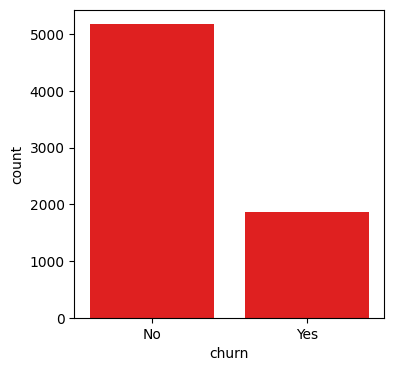

In [ ]:
# churn count plot,visualize no of emp leaving vs stay
plt.figure(figsize=(4,4))
sns.countplot(x='churn',data=df,color='red')
plt.show()

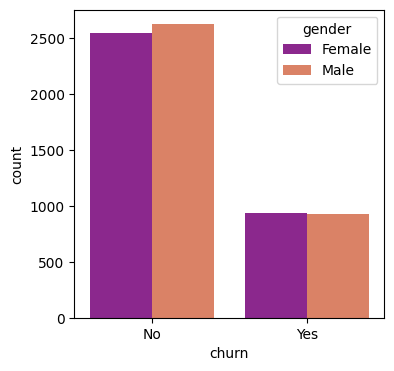

In [ ]:
# churn based on gender
plt.figure(figsize=(4,4))
sns.countplot(x='churn',hue='gender',data=df,palette='plasma')
plt.show()

In [ ]:
df.nunique()

,0
customerid,7043
gender,2
seniorcitizen,2
partner,2
dependents,2
tenure,73
phoneservice,2
multiplelines,3
internetservice,3
onlinesecurity,3


In [ ]:
df.customerid.value_counts()

,count
customerid,
3186-AJIEK,1
7590-VHVEG,1
5575-GNVDE,1
8775-CEBBJ,1
2823-LKABH,1
...,...
6713-OKOMC,1
1452-KIOVK,1
9305-CDSKC,1


In [ ]:

df=df.drop(['customerid','seniorcitizen'],axis=1)


In [ ]:

df=df.drop(['partner'],axis=1)

In [ ]:
df['gender'] = df['gender'].map({'Male':0,'Female':1})


In [ ]:
df['gender'].unique()

array([1, 0])

In [ ]:
df['churn'].unique()

array(['No', 'Yes'], dtype=object)

In [ ]:
df['churn'] = df['churn'].map({'No':0,'Yes':1})

In [ ]:
df['churn'].unique()

array([0, 1])

In [ ]:
df['dependents'] = df['dependents'].map({'No':0,'Yes':1})

In [ ]:
df['dependents'].unique()

array([0, 1])

In [ ]:
df['phoneservice'] = df['phoneservice'].map({'No':0,'Yes':1})

In [ ]:
df['phoneservice'].unique()

array([0, 1])

In [ ]:
df['paperlessbilling'] = df['paperlessbilling'].map({'No':0,'Yes':1})

In [ ]:
df['paperlessbilling'].unique()

array([1, 0])

In [ ]:
df=pd.get_dummies(df,drop_first=True)

In [ ]:
df.columns

Index(['gender', 'dependents', 'tenure', 'phoneservice', 'paperlessbilling',
       'monthlycharges', 'churn', 'multiplelines_No phone service',
       'multiplelines_Yes', 'internetservice_Fiber optic',
       ...
       'totalcharges_995.35', 'totalcharges_996.45', 'totalcharges_996.85',
       'totalcharges_996.95', 'totalcharges_997.65', 'totalcharges_997.75',
       'totalcharges_998.1', 'totalcharges_999.45', 'totalcharges_999.8',
       'totalcharges_999.9'],
      dtype='object', length=6558)

In [ ]:
df.head()

,gender,dependents,tenure,phoneservice,paperlessbilling,monthlycharges,churn,multiplelines_No phone service,multiplelines_Yes,internetservice_Fiber optic,...,totalcharges_995.35,totalcharges_996.45,totalcharges_996.85,totalcharges_996.95,totalcharges_997.65,totalcharges_997.75,totalcharges_998.1,totalcharges_999.45,totalcharges_999.8,totalcharges_999.9
0,1,0,1,0,1,29.85,0,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0,0,34,1,0,56.95,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0,0,2,1,1,53.85,1,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,0,0,45,0,0,42.30,0,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1,0,2,1,1,70.70,1,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
# model implementation

# target sepration

x=df.drop(columns='churn',axis=1)
y=df['churn']

In [ ]:
x.columns

Index(['gender', 'dependents', 'tenure', 'phoneservice', 'paperlessbilling',
       'monthlycharges', 'multiplelines_No phone service', 'multiplelines_Yes',
       'internetservice_Fiber optic', 'internetservice_No',
       ...
       'totalcharges_995.35', 'totalcharges_996.45', 'totalcharges_996.85',
       'totalcharges_996.95', 'totalcharges_997.65', 'totalcharges_997.75',
       'totalcharges_998.1', 'totalcharges_999.45', 'totalcharges_999.8',
       'totalcharges_999.9'],
      dtype='object', length=6557)

In [ ]:
y.name

'churn'

In [ ]:
# train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
x.shape

(7043, 6557)

In [ ]:
x_train.shape

(5634, 6557)

In [ ]:
x_test.shape

(1409, 6557)

In [ ]:
# scaling-preprocessing

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train_scaled,y_train)

LogisticRegression()

In [ ]:
# prediction
y_pread_train = model.predict(x_train_scaled)
y_pread_test = model.predict(x_test_scaled)

In [ ]:
# score
model.score(x_train_scaled,y_train)

0.9904153354632588

In [ ]:
model.score(x_test_scaled,y_test)

0.7750177430801988

In [ ]:
# confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pread_test)
cm

array([[906, 129],
       [188, 186]])

In [ ]:
# classification report
from sklearn.metrics import classification_report
cr = classification_report(y_test,y_pread_test)
print(cr)

              precision    recall  f1-score   support

           0       0.83      0.88      0.85      1035
           1       0.59      0.50      0.54       374

    accuracy                           0.78      1409
   macro avg       0.71      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



In [ ]:
#m implementing another model Decisiopn tree

from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train,y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
# prediction

y_pred_train_dt =dt_model.predict(x_train)
y_pred_test_dt =dt_model.predict(x_test)

In [ ]:
# evaulation- accuracy

from sklearn.metrics import accuracy_score
print('training_accuracy:',accuracy_score(y_train,y_pred_train_dt))
print('Testing_accuracy:',accuracy_score(y_test,y_pred_test_dt))

training_accuracy: 0.9973375931842385
Testing_accuracy: 0.7672107877927609


In [ ]:
# confusion matrix
print("testing confusion matrix")
print(confusion_matrix(y_test,y_pred_test_dt))

testing confusion matrix
[[891 144]
 [184 190]]


In [ ]:
# classification report
print('classification report')
print(classification_report(y_test,y_pred_test_dt))

classification report
              precision    recall  f1-score   support

           0       0.83      0.86      0.84      1035
           1       0.57      0.51      0.54       374

    accuracy                           0.77      1409
   macro avg       0.70      0.68      0.69      1409
weighted avg       0.76      0.77      0.76      1409

